# day-16-rag-architecture — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

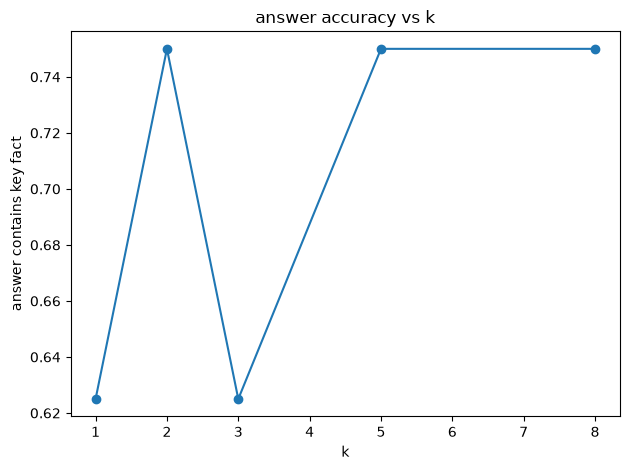

{1: 0.625, 2: 0.75, 3: 0.625, 5: 0.75, 8: 0.75}


In [11]:
# ---- Solution 1 ----
KEYFACT = {
 "how long do standard refunds take": "5 business days",
 "what is the fee for expedited shipping": "$15",
 "how long is a password reset link valid": "1 hour",
 "what HTTP status means rate limited": "429",
 "do you ship internationally": "US and Canada",
 "how do I enable 2FA": "Security settings",
 "what happens to refunds over 500 dollars": "manager approval",
 "how long are API webhooks retried": "24 hours",
}
import matplotlib.pyplot as plt
ks = [1,2,3,5,8]; acc = []
for k in ks:
    hits = 0
    for q, gold in QA:
        ans, _ = rag_answer(q, k)
        hits += KEYFACT[q].lower() in ans.lower()
    acc.append(hits/len(QA))
plt.plot(ks, acc, marker="o"); plt.xlabel("k"); plt.ylabel("answer contains key fact")
plt.title("answer accuracy vs k"); plt.tight_layout(); plt.show()
print(dict(zip(ks, acc)))

In [12]:
# ---- Solution 5 ----
# Post-hoc attribution: for each answer sentence that restates the key fact, is the chunk we
# attribute it to one that actually contains that fact?
faithful, total = 0, 0
for q, fact in KEYFACT.items():
    chunks = retrieve(q, 4)
    ans = generate(*build_prompt(q, chunks))
    for sent, doc, sim in posthoc_attribution(ans, chunks):
        if fact.lower() in sent.lower():
            total += 1
            best = next(c for c in chunks if c["doc"] == doc)
            faithful += fact.lower() in best["text"].lower()
print(f"S5: faithful attributions = {faithful}/{total}" if total else
      "S5: no answer sentence restated the key fact strongly enough to attribute")
print("    (faithful = the chunk we attribute the fact-sentence to actually contains that fact)")

S5: faithful attributions = 1/1
    (faithful = the chunk we attribute the fact-sentence to actually contains that fact)


### Solutions 2, 3, 4, 6 (sketch)

**S2:** in-scope answered = `mean(gated(q) != 'No sufficiently relevant...' for q in QA)`;
out-of-scope refused = `mean(gated(q).startswith('No sufficiently') for q in oos)`. As the
threshold rises, refusals go up (good for OOS, bad if it starts refusing real questions).
Pick where the OOS-refuse rate is ~1.0 and the in-scope-answer rate is still ~1.0 — often
~0.25–0.35 for MiniLM cosine.

**S3:** with `overlap=0`, a fact that sits at character ~275–285 of a doc gets split: the
first chunk ends mid-sentence, the second starts mid-sentence, and neither embeds well for the
query. Overlap of ~15% keeps the whole fact in at least one chunk. This is the core Day 17
lesson.

**S4:** move `chunks[0]` to the end of the list before `build_prompt`. Small models are quite
position-sensitive; you'll often see the answer quality drop when the key chunk is in the
middle of 6, and recover when it's first or last.

**S6:** `promotions.md` with "price-drop refund" language embeds near refund queries. For
*"how long do refunds take"* it may rank #1 and the model answers about price-matching instead.
Fix: (a) a cross-encoder reranker re-scores the top-20 and demotes the off-topic chunk;
(b) hybrid BM25+vector (Day 13) — the exact phrase "5 business days" lives only in the real
doc; (c) metadata filter on `doc_type`.

### Answer key
1. Access to private / current / large corpora the model was never trained on (and can't fit
   whole in context) — plus provenance: you can show *which* passage the answer came from.
2. Offline: load, chunk, embed, store. Per-query: embed query, retrieve top-k, build prompt,
   generate, extract citations.
3. Too small: the passage containing the answer may not be retrieved → "I don't know" or
   wrong. Too large: irrelevant chunks dilute the prompt, trigger lost-in-the-middle, and cost
   tokens/latency.
4. (a) Answer using only the provided context; (b) say "I don't know based on the provided
   context" when the answer isn't there (and, usually, cite passage numbers).
5. The retrieve/generate boundary — there was no relevance gate, so low-similarity chunks were
   still sent to the LLM which answered anyway. Fix: a similarity threshold that short-circuits
   to "no relevant info", plus the strict system prompt.
6. A citation is faithful if the passage it points to actually contains the fact the answer
   states. Check it because models cite plausibly even when the fact came from elsewhere (or
   was invented) — unfaithful citations destroy user trust and hide hallucinations.
7. Any two: cross-encoder reranker over the top-N; hybrid keyword+vector retrieval; metadata
   filtering; better chunking so the real answer's chunk is more distinctive; query rewriting.